# `MGHybridBoostPk`: Binned Modified Gravity Boost Emulator

This notebook introduces `MGHybridBoostPk`, CCL's hybrid neural-network
emulator for the phenomenological binned modified gravity (MG) boost.

**Physical setup.** The MG parameters $\mu$ and $\eta$ are allowed to
deviate from their GR values ($\mu=\eta=1$) independently within 5
redshift bins:

| `bin_index` | Redshift range |
|---|---|
| 0 | $0.0 \le z < 0.43$ |
| 1 | $0.43 \le z < 0.91$ |
| 2 | $0.91 \le z < 1.47$ |
| 3 | $1.47 \le z < 2.15$ |
| 4 | $2.15 \le z < 3.0$ |

`MGHybridBoostPk` takes `mus` and `etas` as length-5 arrays (one value
per bin) and internally routes the calculation to one of two trained
backends for $\mu,\eta \in [0.9, 1.1]$. Values
outside that range trigger a `UserWarning` and should be treated as
extrapolation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl


## 1. Setting up a cosmology

 `MGHybridBoostPk` is passed to`matter_power_spectrum` in `ccl.Cosmology`. Note that the emulators
were trained on `A_s`, not `sigma8` -- see the note in Section 6.


In [2]:
cosmo = ccl.Cosmology(
    Omega_c=0.31 - 0.049,
    Omega_b=0.049,
    h=0.67,
    n_s=0.96,
    A_s=2.1e-9,
    Neff=3.046,
    m_nu=0.0,
    Omega_g=0,
    Omega_k=0,
    w0=-1,
    wa=0,
    transfer_function='boltzmann_camb'
)

z = 0.05
a = 1.0 / (1.0 + z)


## 2. The GR (all-mu=1) case

In [ ]:
bemu_gr = ccl.MGHybridBoostPk(mus=None,etas=None) # Instantiates the MG boost emulator( emualtor class integrated into CCL)
                                #  k_arr can optionally be passed to choose the k-grid the boost is
                                # interpolated onto (default: 200 log-spaced points, 1e-3 to 1.0 h/Mpc).
                                # z_arr can optionally be passed to choose the z-grid the boost is
                                 # interpolated onto (default: 30 log-spaced points, 1e-2 to 3.0 ).
                                # dafault case of mus and etas are GR.
cosmo_gr = ccl.Cosmology(
    Omega_c=0.31 - 0.049, Omega_b=0.049, h=0.67, n_s=0.96, A_s=2.1e-9
)

pk2d_gr = bemu_gr.get_pk2d(cosmo_gr) # calling function to compute power spectra


/opt/homebrew/Caskroom/miniconda/base/envs/ccl_env/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.5.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


10
(10, 1024)
[0.32058351 0.04777709 0.6977839  0.98448356 3.06970988 1.00085614
 0.99976148 1.00042199 1.00031791 0.9994059  0.87284615]
[[ 9.60331932e-02  2.75041498e-02 -8.26101676e-02  7.98280910e-02
  -1.59129128e-01  3.39162350e-01  2.06909124e-02 -6.76242262e-02
   2.17104098e-03 -1.18030779e-01]
 [ 9.67172012e-02  2.64993962e-02 -8.23178813e-02  7.79647231e-02
  -1.58597007e-01  3.36712122e-01  2.08431166e-02 -6.75772578e-02
   1.77866826e-03 -1.17465876e-01]
 [ 9.74885821e-02  2.53305025e-02 -8.19848776e-02  7.57764652e-02
  -1.58019453e-01  3.33765566e-01  2.09621284e-02 -6.75846711e-02
   1.17647415e-03 -1.16437405e-01]
 [ 9.83302072e-02  2.39893924e-02 -8.16138536e-02  7.32392892e-02
  -1.57425299e-01  3.30237627e-01  2.10246295e-02 -6.76939636e-02
   2.70143850e-04 -1.14707850e-01]
 [ 9.92156640e-02  2.24971212e-02 -8.12205672e-02  7.03476071e-02
  -1.56862527e-01  3.26031327e-01  2.10020673e-02 -6.79801255e-02
  -1.06571196e-03 -1.11949764e-01]
 [ 1.00079924e-01  2.091520

## 3. Single-bin case:

Setting only `mus[0] != 1`, with every other bin at GR

In [ ]:
bemu_bin0 = ccl.MGHybridBoostPk(mus=[1.05, 1.0, 1.0, 1.0, 1.0]) # here bin indices are arranged from the lowest bin to highest bin

cosmo_bin0 = ccl.Cosmology(
    Omega_c=0.31 - 0.049, Omega_b=0.049, h=0.67, n_s=0.96, A_s=2.1e-9
)

pk2d_bin0 = bemu_bin0.get_pk2d(cosmo_bin0)
print("modified bins:", bemu_bin0.modified_bins)


/opt/homebrew/Caskroom/miniconda/base/envs/ccl_env/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.5.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


10
(10, 1024)
[0.32058351 0.04777709 0.6977839  0.98448356 3.06970988 1.00085614
 0.99976148 1.00042199 1.00031791 0.9994059  0.87284615]
modified bins: [0]


## 4. Multi-bin case:



In [ ]:
bemu_multi = ccl.MGHybridBoostPk(mus=[1.1, 1.1, 1.1, 1.1, 1.1]) # But in multi-bin the indices are from highest to lowest bin

cosmo_multi = ccl.Cosmology(
    Omega_c=0.31 - 0.049, Omega_b=0.049, h=0.67, n_s=0.96, A_s=2.1e-9,
)

pk2d_multi = bemu_multi.get_pk2d(cosmo_multi)
print("modified bins:", bemu_multi.modified_bins)


10
(10, 1024)
[0.32058351 0.04777709 0.6977839  0.98448356 3.06970988 1.00085614
 0.99976148 1.00042199 1.00031791 0.9994059  0.87284615]
[[ 9.1010422e-01  4.2620921e+00  2.7330639e+00  8.1076020e-01
   1.8312272e+00 -5.5934196e+00 -1.9080226e+00  1.1000484e-01
   3.4678388e+00 -2.3473082e+00]
 [ 9.0869933e-01  4.2563043e+00  2.7356324e+00  8.0876034e-01
   1.8095268e+00 -5.5735178e+00 -1.8929566e+00  9.9497236e-02
   3.4484673e+00 -2.3413408e+00]
 [ 9.0690827e-01  4.2492070e+00  2.7388189e+00  8.0650896e-01
   1.7828199e+00 -5.5488725e+00 -1.8747929e+00  8.6636424e-02
   3.4245234e+00 -2.3336725e+00]
 [ 9.0461367e-01  4.2404962e+00  2.7427759e+00  8.0405194e-01
   1.7498807e+00 -5.5182524e+00 -1.8529477e+00  7.0891850e-02
   3.3948305e+00 -2.3237298e+00]
 [ 9.0165037e-01  4.2297831e+00  2.7477012e+00  8.0147213e-01
   1.7091441e+00 -5.4800744e+00 -1.8267411e+00  5.1617868e-02
   3.3578377e+00 -2.3106947e+00]
 [ 8.9780587e-01  4.2165999e+00  2.7538319e+00  7.9893404e-01
   1.6586111e+0

/opt/homebrew/Caskroom/miniconda/base/envs/ccl_env/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.5.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


modified bins: [0, 1, 2, 3, 4]


## 5. `get_pk2d`: the full hybrid power spectrum

`get_pk2d(cosmo)` returns a `Pk2D` object:

$$P_{\rm MG}(k,z) = P_{\rm LCDM,\ full}(k,z) \times B_{\rm full}(k,z)$$

where $B_{\rm full}$ is the FULL hybrid boost - the linear-NN and
nonlinear-NN/GP contributions already blended together via the
$k$-dependent weighting. Note this multiplies onto
the **full** LCDM baseline across the *entire* $k$ range.


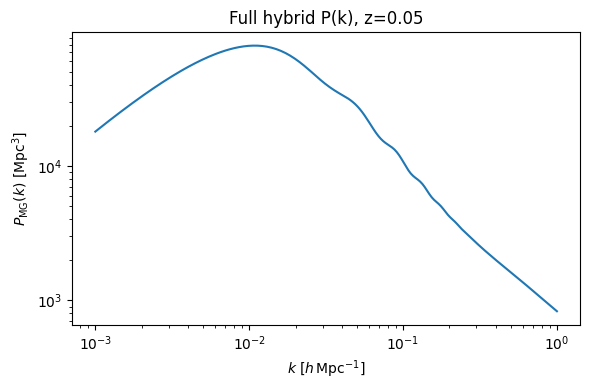

In [ ]:
k_hmpc = np.logspace(-3, 0, 200) # defining the k-grid we require our P(k) on
k_ccl = k_hmpc 

P_full = np.array([pk2d_bin0(k, a, cosmo_bin0) for k in k_ccl])# calling our power spectrum and converting it into an array of values in k_ccl

plt.figure(figsize=(6, 4))
plt.loglog(k_hmpc, P_full)
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P_{\rm MG}(k)\ [\mathrm{Mpc}^3]$")
plt.title(f"Full hybrid P(k), z={z}")
plt.tight_layout()
plt.show()


## 6. `get_linear_pk`: the linear-only power spectrum

$$P_{\rm MG,\ linear}(k,z) = P_{\rm LCDM,\ linear}(k,z) \times B_{\rm linear}(k,z)$$

Here $B_{\rm linear}$ is the linear-NN boost component alone - the
value it has before being blended with the nonlinear component, obtained by calling the linear sub-emulator directly.


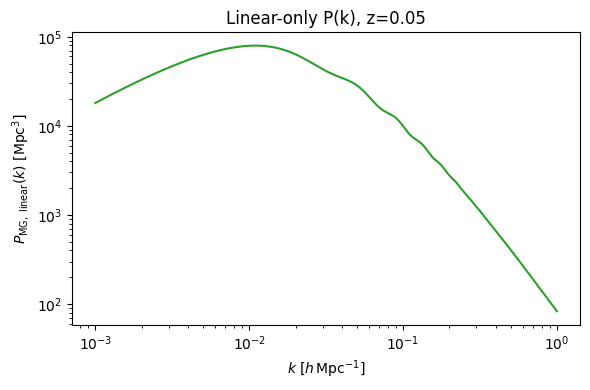

In [ ]:
pk2d_lin = bemu_bin0.get_linear_pk(cosmo_bin0)# calling function inside MGHybridBoost class for linear power spectrum
P_lin = np.array([pk2d_lin(k, a, cosmo_bin0) for k in k_ccl])

plt.figure(figsize=(6, 4))
plt.loglog(k_hmpc, P_lin, color="tab:green")
#plt.loglog(k_hmpc,P_full)
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P_{\rm MG,\ linear}(k)\ [\mathrm{Mpc}^3]$")
plt.title(f"Linear-only P(k), z={z}")
plt.tight_layout()
plt.show()


## 8. Comparing all two `P(k)` variants

 Plotting `get_pk2d` and `get_linear_pk` together makes the distinction concrete:


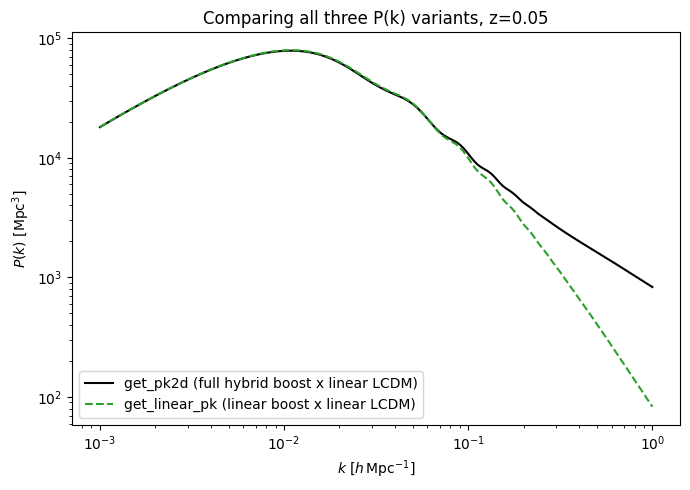

In [8]:
plt.figure(figsize=(7, 5))
plt.loglog(k_hmpc, P_full, label="get_pk2d (full hybrid boost x linear LCDM)", color="black")
plt.loglog(k_hmpc, P_lin, label="get_linear_pk (linear boost x linear LCDM)", color="tab:green", linestyle="--")
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P(k)\ [\mathrm{Mpc}^3]$")
plt.title(f"Comparing all three P(k) variants, z={z}")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Comparing `P(k)` variants for the multi_bin case

 Plotting `get_pk2d` and `get_linear_pk`together for the multi_bin={mus=[1.1, 1.1, 1.1, 1.1, 1.1]}

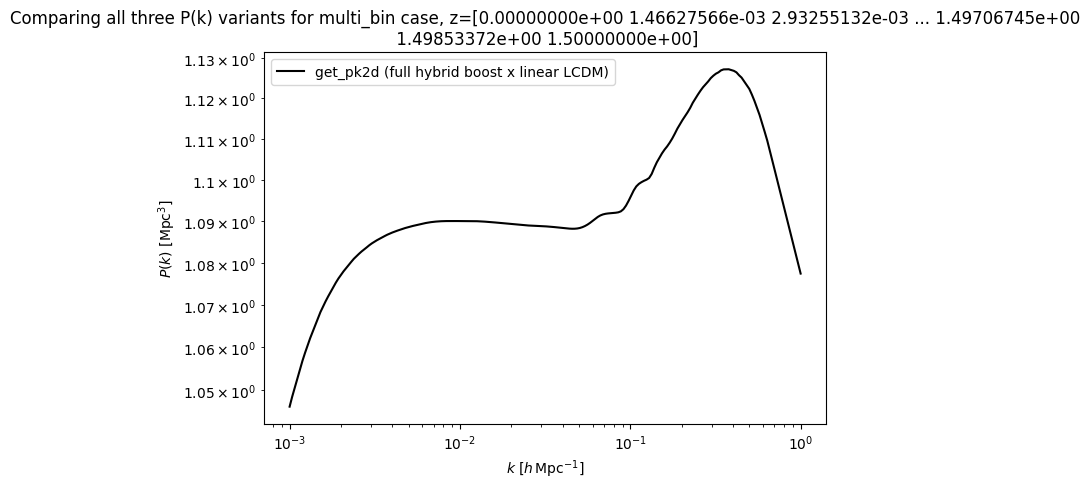

In [ ]:
P_full_multi = np.array([pk2d_multi(k, a, cosmo_multi) for k in k_ccl])
pk2d_lin_multi = bemu_multi.get_linear_pk(cosmo_multi)
P_lin_multi = np.array([pk2d_lin_multi(k, a, cosmo_multi) for k in k_ccl])
plt.figure(figsize=(7, 5))
plt.loglog(k_hmpc, P_full_multi, label="get_pk2d (full hybrid boost x linear LCDM)", color="black")
plt.loglog(k_hmpc, P_lin_multi, label="get_linear_pk (linear boost x linear LCDM)", color="tab:green", linestyle="--")
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P(k)\ [\mathrm{Mpc}^3]$")
plt.title(f"Comparing all three P(k) variants for multi_bin case, z={z}")
plt.legend()
plt.tight_layout()
plt.show()

## 9. `boost`: the raw stitched boost values directly

If you only want the boost itself - $B(k,z) = P_{\rm MG}/P_{\rm LCDM}$,
the full linear+nonlinear blend,
`boost(cosmo)` returns it directly:

```python
k_arr, z_arr, boost_grid = bemu.boost(cosmo)
```
Since boost_grid returns boost as a function of of k and z, you choose the one row closest to your desired z to plot here.



boost_grid shape: (30, 200) -> (n_z, n_k)


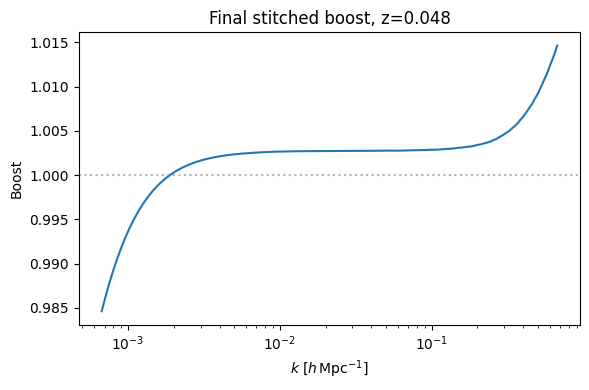

In [ ]:
k_arr, z_arr, boost_grid = bemu_bin0.boost(cosmo_bin0)# boost function returns boost values corresponding to a k_arr and z_arr.
                                                      # you can choose your own k_arr which should have be passed inside bemu_bin0 alongside mus, 
                                                       # but if not mentioned it resets to default 1e-3 - 0 range.

print("boost_grid shape:", boost_grid.shape, "-> (n_z, n_k)")

iz = np.argmin(np.abs(z_arr - z))# finding boost at a z value inside z_arr thats closest to our desired z
boost_at_z = boost_grid[iz]

plt.figure(figsize=(6, 4))
plt.semilogx(k_arr, boost_at_z, color="tab:blue") 
plt.axhline(1.0, color="gray", linestyle=":", alpha=0.6)
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel("Boost")
plt.title(f"Final stitched boost, z={z_arr[iz]:.3f}")
plt.tight_layout()
plt.show()


## 10. Custom `k_arr` / `z_arr`

Both grids can be overridden at construction time. This matters in
particular for `z=0`: the default `z_arr` is 30 points log-spaced from
`z=0.01` to `z=3.0` and does NOT include `z=0` exactly -- but a query
at `z=0` (`a=1`) is common enough that a special case was added so the
default grid explicitly includes it. If you supply your own `z_arr`,
make sure it covers whatever redshift you actually plan to query, or
CCL will be extrapolating past the edge of its spline rather than
interpolating.


In [11]:
bemu_custom = ccl.MGHybridBoostPk(
    mus=[1.05, 1.0, 1.0, 1.0, 1.0],
    z_arr=np.linspace(0.0, 2.0, 40),
    k_arr=np.logspace(-3, 0, 300),
)

cosmo_custom = ccl.Cosmology(
    Omega_c=0.31 - 0.049, Omega_b=0.049, h=0.67, n_s=0.96, A_s=2.1e-9,
)

pk2d_custom = bemu_custom.get_pk2d(cosmo_custom)
print(pk2d_custom(0.1 * cosmo_custom['h'], 1.0, cosmo_custom))   # z=0 query


10
(10, 1024)
[0.32058351 0.04777709 0.6977839  0.98448356 3.06970988 1.00085614
 0.99976148 1.00042199 1.00031791 0.9994059  0.87284615]


/opt/homebrew/Caskroom/miniconda/base/envs/ccl_env/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.5.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


18494.464473933625


## Computing lensing $C_\ell$ with a custom Modified-Gravity tracer

The MG boost emulator gives us $P_{\delta,\rm MG}(k,z)$ - the $\mu$-boosted
matter power spectrum. To get a physically correct lensing $C_\ell$, the
$\Sigma$ modification needs to enter separately, since lensing responds to
$\Sigma$ rather than $\mu$ alone.

Because $\Sigma$ in this parametrization is flat in $k$ (one amplitude per
redshift bin, same convention as `mus=[...]`), the cleanest way to apply it
is by rescaling the **lensing kernel** directly. This means the same `pk_mu` object can be reused
for shear-shear, galaxy-galaxy lensing, and clustering alike — each
combination automatically picks up the correct power of $\Sigma$ from
however many lensing legs it has.

In [12]:
# Redshift distribution for a single source bin
z = np.linspace(0, 1.5, 1024)
nz = np.exp(-((z - 0.65) / 0.05)**2 / 2)

# Standard CCL lensing kernel geometry 
chis, w_lens = ccl.get_lensing_kernel(cosmo_multi, dndz=(z, nz))

# Per-bin Sigma amplitudes (flat-in-k), same bin structure as mus=[...]
mus=np.array([1.05, 0.97, 0.9, 1.0, 1.09])
eta=np.array([1.0, 1.0, 1.0, 1.0, 1.0])
sigmas = 0.5 * mus * (1 + eta)
z_edges = np.array([0.00, 0.43, 0.91, 1.47, 2.15, 3.00])
z_bin_centers = 0.5 * (z_edges[:-1] + z_edges[1:]) # CONFIRM: actual bin centers

# Interpolate Sigma(z) onto the chi grid used by the lensing kernel
a_of_chi = ccl.scale_factor_of_chi(cosmo_multi, chis)
z_of_chi = 1. / a_of_chi - 1.
sigma_of_chi = np.interp(z_of_chi, z_bin_centers, sigmas)

# Rescale the kernel by Sigma(chi)
kernel_mg = (chis, w_lens * sigma_of_chi)

In [13]:
# Build the custom MG-aware lensing tracer
wl_mg = ccl.Tracer()
wl_mg.add_tracer(cosmo_multi, kernel=kernel_mg, der_bessel=-1, der_angles=2)
# der_bessel/der_angles here match the standard weak-lensing shear term

# The mu-boosted matter power spectrum from the emulator — no Sigma baked in,
pk_mu = bemu_multi.get_pk2d(cosmo_multi) 


[[ 9.1010422e-01  4.2620921e+00  2.7330639e+00  8.1076020e-01
   1.8312272e+00 -5.5934196e+00 -1.9080226e+00  1.1000484e-01
   3.4678388e+00 -2.3473082e+00]
 [ 9.0869933e-01  4.2563043e+00  2.7356324e+00  8.0876034e-01
   1.8095268e+00 -5.5735178e+00 -1.8929566e+00  9.9497236e-02
   3.4484673e+00 -2.3413408e+00]
 [ 9.0690827e-01  4.2492070e+00  2.7388189e+00  8.0650896e-01
   1.7828199e+00 -5.5488725e+00 -1.8747929e+00  8.6636424e-02
   3.4245234e+00 -2.3336725e+00]
 [ 9.0461367e-01  4.2404962e+00  2.7427759e+00  8.0405194e-01
   1.7498807e+00 -5.5182524e+00 -1.8529477e+00  7.0891850e-02
   3.3948305e+00 -2.3237298e+00]
 [ 9.0165037e-01  4.2297831e+00  2.7477012e+00  8.0147213e-01
   1.7091441e+00 -5.4800744e+00 -1.8267411e+00  5.1617868e-02
   3.3578377e+00 -2.3106947e+00]
 [ 8.9780587e-01  4.2165999e+00  2.7538319e+00  7.9893404e-01
   1.6586111e+00 -5.4322810e+00 -1.7954172e+00  2.8038913e-02
   3.3115094e+00 -2.2934160e+00]
 [ 8.9280850e-01  4.2003555e+00  2.7614589e+00  7.9670304e

In [ ]:
ells = np.geomspace(2, 2000, 30) # construct l-grid for Cl
cl_kappa_mg = ccl.angular_cl(cosmo_multi, wl_mg, wl_mg, ells, p_of_k_a=pk_mu)

## Example plot

A quick look at the resulting shear-shear angular power spectrum.

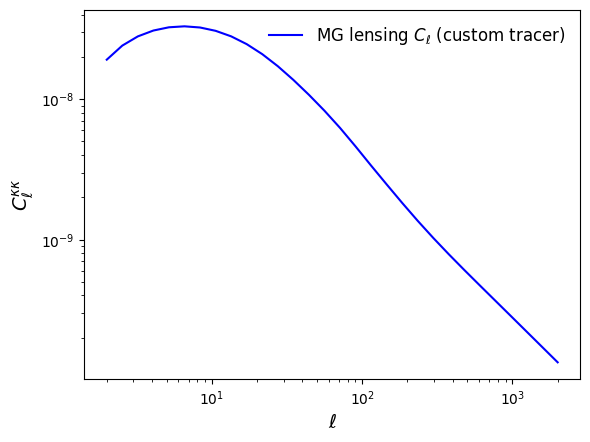

In [15]:
plt.plot(ells, cl_kappa_mg, 'b-', label='MG lensing $C_\\ell$ (custom tracer)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\\ell$', fontsize=14)
plt.ylabel('$C_\\ell^{\\kappa\\kappa}$', fontsize=14)
plt.legend(loc='upper right', fontsize=12, frameon=False)
plt.show()

## Comparing $\Lambda$CDM to single-bin and multi-bin MG scenarios

We now compute the lensing $C_\ell$ for:
1. Plain $\Lambda$CDM (GR, no MG boost)
2. Single-bin MG: only bin 0 modified
3. Single-bin MG: only bin 4 modified
4. Multi-bin MG: the `cosmo_multi` case above (all bins vary)
5. Multi-bin MG: a second, different multi-bin combination

and plot them together to see how the deviation from $\Lambda$CDM depends on
which redshift bin(s) carry the modification.

In [16]:
BASE_PARAMS = dict(
    Omega_c=0.31 - 0.049, Omega_b=0.049, h=0.67, n_s=0.96, A_s=2.1e-9,
) 

ells = np.geomspace(2, 2000, 30)

In [17]:
def mg_lensing_cl(mus, eta, label):

    mus = np.asarray(mus)
    eta = np.asarray(eta)
    sigmas = 0.5 * mus * (1 + eta)

    bemu = ccl.MGHybridBoostPk(mus=mus)
    cosmo = ccl.Cosmology(**BASE_PARAMS)

    chis, w_lens = ccl.get_lensing_kernel(cosmo, dndz=(z, nz))
    a_of_chi = ccl.scale_factor_of_chi(cosmo, chis)
    z_of_chi = 1. / a_of_chi - 1.
    sigma_of_chi = np.interp(z_of_chi, z_bin_centers, sigmas)
    kernel_mg = (chis, w_lens * sigma_of_chi)

    wl_mg = ccl.Tracer()
    wl_mg.add_tracer(cosmo, kernel=kernel_mg, der_bessel=-1, der_angles=2)

    pk_mu = bemu.get_pk2d(cosmo)

    cl = ccl.angular_cl(cosmo, wl_mg, wl_mg, ells, p_of_k_a=pk_mu)
    return label, cl

In [ ]:

cosmo_lcdm = ccl.Cosmology(**BASE_PARAMS)         # constructing Cl using standard built in tracers for LCDM 
wl_lcdm = ccl.WeakLensingTracer(cosmo_lcdm, dndz=(z, nz))
cl_lcdm = ccl.angular_cl(cosmo_lcdm, wl_lcdm, wl_lcdm, ells)


eta_gr = np.ones(5)  

cases = [
    mg_lensing_cl([1.05, 1.00, 1.00, 1.00, 1.00], eta_gr, r'bin 0 only ($\mu_0=1.05$)'),
    mg_lensing_cl([1.00, 1.00, 1.00, 1.00, 0.9], eta_gr, r'bin 4 only ($\mu_4=0.9$)'),
    mg_lensing_cl([1.1, 1.1, 1.1, 1.1, 1.1],eta_gr, 'multi-bin 1 ($\mu_1,\mu_3,\mu_4,\mu_5$) '),
    mg_lensing_cl([1.00, 1.1, 1.00, 0.9, 1.00], eta_gr, r'multi-bin 2 ($\mu_2,\mu_4$,\mu_5$)'),
]

/opt/homebrew/Caskroom/miniconda/base/envs/ccl_env/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.5.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


10
(10, 1024)
[0.32058351 0.04777709 0.6977839  0.98448356 3.06970988 1.00085614
 0.99976148 1.00042199 1.00031791 0.9994059  0.87284615]


/opt/homebrew/Caskroom/miniconda/base/envs/ccl_env/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.5.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


10
(10, 1024)
[0.32058351 0.04777709 0.6977839  0.98448356 3.06970988 1.00085614
 0.99976148 1.00042199 1.00031791 0.9994059  0.87284615]


/opt/homebrew/Caskroom/miniconda/base/envs/ccl_env/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.5.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


10
(10, 1024)
[0.32058351 0.04777709 0.6977839  0.98448356 3.06970988 1.00085614
 0.99976148 1.00042199 1.00031791 0.9994059  0.87284615]
[[ 2.17629242e+00  2.73951411e-01 -8.27195644e-01  2.78679490e+00
   1.05758354e-01  9.64806318e-01 -6.04871869e-01  1.20858693e+00
   1.12256682e+00 -4.74478871e-01]
 [ 2.17996669e+00  2.71872729e-01 -8.32273543e-01  2.77684593e+00
   1.23487502e-01  9.49948668e-01 -6.15470946e-01  1.20932770e+00
   1.11979055e+00 -4.67859238e-01]
 [ 2.18448544e+00  2.69172013e-01 -8.38203430e-01  2.76471376e+00
   1.44959733e-01  9.31819439e-01 -6.28316462e-01  1.20998716e+00
   1.11570406e+00 -4.59909350e-01]
 [ 2.19003534e+00  2.65629441e-01 -8.45031917e-01  2.74993396e+00
   1.70924053e-01  9.09690499e-01 -6.43839359e-01  1.21044040e+00
   1.10967493e+00 -4.50416595e-01]
 [ 2.19684911e+00  2.60917068e-01 -8.52741420e-01  2.73198485e+00
   2.02242404e-01  8.82662475e-01 -6.62527502e-01  1.21049523e+00
   1.10077226e+00 -4.39176738e-01]
 [ 2.20517492e+00  2.545667

/Users/ajiv/CCL/pyccl/emulators/mg_hybrid_boost_pk.py:225: UserWarning: MGHybridBoostPk: mus[1]=1.12 outside training range [0.9, 1.1]. Accuracy not guaranteed.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ccl_env/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.5.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


10
(10, 1024)
[0.32058351 0.04777709 0.6977839  0.98448356 3.06970988 1.00085614
 0.99976148 1.00042199 1.00031791 0.9994059  0.87284615]
[[-5.38462818e-01 -5.19690216e-01  4.13760394e-01 -1.10521272e-01
   2.62691402e+00 -1.01290911e-01 -3.54920864e+00  1.46349931e+00
   2.46110535e+00  8.76453757e-01]
 [-5.35327315e-01 -5.28896570e-01  4.16680217e-01 -1.37483463e-01
   2.64537835e+00 -1.31680682e-01 -3.52728748e+00  1.46529031e+00
   2.44903111e+00  8.87454033e-01]
 [-5.31354606e-01 -5.40361404e-01  4.20599967e-01 -1.70966282e-01
   2.66773701e+00 -1.68782696e-01 -3.50029969e+00  1.46740437e+00
   2.43410897e+00  9.00597394e-01]
 [-5.26288450e-01 -5.54701209e-01  4.25925463e-01 -2.12687105e-01
   2.69474792e+00 -2.14072451e-01 -3.46700287e+00  1.46987331e+00
   2.41561675e+00  9.16197240e-01]
 [-5.19787073e-01 -5.72728276e-01  4.33239639e-01 -2.64873952e-01
   2.72725558e+00 -2.69329488e-01 -3.42584705e+00  1.47269547e+00
   2.39260626e+00  9.34539437e-01]
 [-5.11403739e-01 -5.955138

## Plotting all cases together

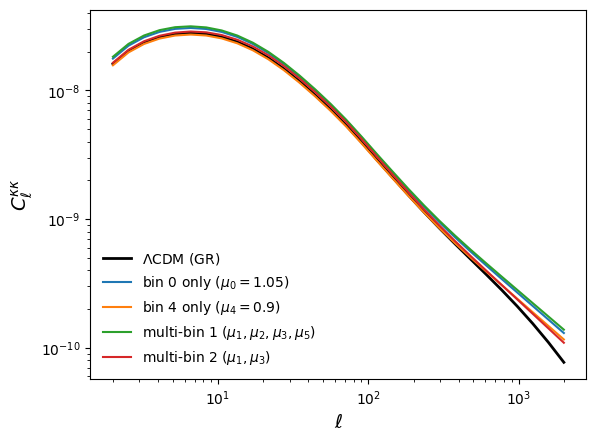

In [19]:
plt.figure()
plt.plot(ells, cl_lcdm, 'k-', lw=2, label=r'$\Lambda$CDM (GR)')
for label, cl in cases:
    plt.plot(ells, cl, label=label)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=14)
plt.ylabel(r'$C_\ell^{\kappa\kappa}$', fontsize=14)
plt.legend(fontsize=10, frameon=False)
plt.show()


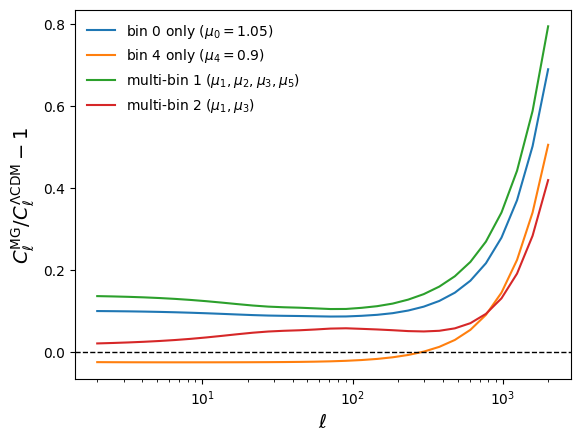

In [20]:
plt.figure()
for label, cl in cases:
    plt.plot(ells, cl / cl_lcdm - 1, label=label)
plt.axhline(0, color='k', lw=1, ls='--')
plt.xscale('log')
plt.xlabel(r'$\ell$', fontsize=14)
plt.ylabel(r'$C_\ell^{\rm MG}/C_\ell^{\Lambda\rm CDM} - 1$', fontsize=14)
plt.legend(fontsize=10, frameon=False)
plt.show()

## 11. Validated parameter ranges -- summary

| Parameter | Trained/validated range | Notes |
|---|---|---|
| `mu`, `eta` (per bin) | $[0.9, 1.1]$ | `UserWarning` outside this range |
| `Omega_m` | $[0.24, 0.4]$ | |
| `Omega_b` | $[0.04, 0.055]$ | |
| `h` | $[0.65, 0.75]$ | |
| `n_s` | $[0.8, 1.2]$ | |
| `A_s` | $\approx[1.9, 2.5]\times 10^{-9}$ | must be set directly (not `sigma8`) |
| `z` | $[0.0, 3.0]$ | |
| `k` | up to $k=1\,h\,{\rm Mpc}^{-1}$ recommended | COLA simulation accuracy limit; single-bin backend valid to $k=10$, multi-bin confirmed trained to $k=10$ but with growing GP/NN disagreement above $k\sim1$ |

Querying outside these ranges will not raise an error (except `A_s`
being unset, which raises `ValueError`), only warnings where checked
-- treat any such result as unvalidated extrapolation.
